# Forecasting Future Electric Vehicle Adoption in the UK

This notebook develops a forecasting model to predict future electric vehicle (EV) registrations in the United Kingdom using historical quarterly registration data.

The forecasting analysis builds on the cleaned and integrated dataset prepared in the previous notebooks. Quarterly EV registration totals are aggregated to create a national time series that represents the growth of EV adoption over time.

A forecasting model is then developed and evaluated using historical observations before being used to estimate future registration trends. The results help answer the third research question by identifying likely future patterns in EV adoption and providing evidence that can support transport planning and policy development.

## Import Required Libraries

The libraries below are used for data handling, time series preparation, forecasting, model evaluation and visualisation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

## Load the Processed Dataset

The forecasting model uses the cleaned EV registration dataset prepared in the previous notebooks.

In [2]:
project_folder = Path.cwd().parent

processed_folder = project_folder / "Datasets" / "processed"

figures_folder = project_folder / "Figures"

tables_folder = project_folder / "Tables"

ev_uk = pd.read_csv(
    processed_folder / "ev_clean.csv",
    low_memory=False
)

print(ev_uk.shape)

ev_uk.head()

(285505, 62)


,LSOA21CD,LSOA21NM,Fuel,Keepership,2026 Q1,2025 Q4,2025 Q3,2025 Q2,2025 Q1,2024 Q4,...,2014 Q1,2013 Q4,2013 Q3,2013 Q2,2013 Q1,2012 Q4,2012 Q3,2012 Q2,2012 Q1,2011 Q4
0,E01000001,City of London 001A,Battery electric,Company,13.0,10.0,10.0,10.0,9.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,E01000002,City of London 001B,Battery electric,Company,12.0,14.0,11.0,11.0,12.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,E01000005,City of London 001E,Battery electric,Company,18.0,18.0,22.0,21.0,18.0,18.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,E01000007,Barking and Dagenham 015A,Battery electric,Company,7.0,8.0,8.0,9.0,9.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,E01000008,Barking and Dagenham 015B,Battery electric,Company,134.0,129.0,125.0,124.0,117.0,99.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Prepare National Quarterly EV Registration Time Series

The forecasting analysis uses national quarterly EV registration totals. To avoid double counting, only the published total vehicle counts are selected before aggregating registrations across all quarters.

In [3]:
# Keep only published national totals

forecast_data = ev_uk[
    (ev_uk["Fuel"] == "Total") &
    (ev_uk["Keepership"] == "Total")
].copy()

print("Rows:", len(forecast_data))
forecast_data.head()

Rows: 42788


,LSOA21CD,LSOA21NM,Fuel,Keepership,2026 Q1,2025 Q4,2025 Q3,2025 Q2,2025 Q1,2024 Q4,...,2014 Q1,2013 Q4,2013 Q3,2013 Q2,2013 Q1,2012 Q4,2012 Q3,2012 Q2,2012 Q1,2011 Q4
242717,E01000001,City of London 001A,Total,Total,48.0,38.0,38.0,38.0,41.0,41.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
242718,E01000002,City of London 001B,Total,Total,48.0,53.0,49.0,45.0,46.0,39.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242719,E01000003,City of London 001C,Total,Total,30.0,29.0,27.0,25.0,23.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
242720,E01000005,City of London 001E,Total,Total,29.0,27.0,30.0,27.0,24.0,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
242721,E01000006,Barking and Dagenham 016A,Total,Total,51.0,46.0,46.0,41.0,42.0,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Build the National Quarterly Time Series

Quarterly EV registrations are aggregated to produce a single national time series. This forms the input for the forecasting models developed later in this notebook.

In [4]:
# Quarterly columns

quarter_columns = [
    c for c in forecast_data.columns
    if "Q" in c
]

# Sort chronologically

quarter_columns = sorted(
    quarter_columns,
    key=lambda x: (
        int(x.split()[0]),
        int(x.split()[1][1])
    )
)

# National quarterly totals

national_series = (
    forecast_data[quarter_columns]
    .sum()
    .reset_index()
)

national_series.columns = [
    "Quarter",
    "EV_Registrations"
]

national_series.head()

,Quarter,EV_Registrations
0,2011 Q4,4657.0
1,2012 Q1,4935.0
2,2012 Q2,5335.0
3,2012 Q3,5363.0
4,2012 Q4,5852.0


## Convert Quarterly Data to a Time Series

The aggregated quarterly registrations are converted into a time-series format. This allows forecasting models to recognise the chronological order of observations.

In [5]:
# Convert Quarter into datetime

quarter_map = {
    "Q1": "-01-01",
    "Q2": "-04-01",
    "Q3": "-07-01",
    "Q4": "-10-01"
}

national_series["Date"] = national_series["Quarter"].apply(
    lambda x: x.split()[0] + quarter_map[x.split()[1]]
)

national_series["Date"] = pd.to_datetime(national_series["Date"])

national_series = national_series[
    ["Date", "Quarter", "EV_Registrations"]
]

national_series.head()

,Date,Quarter,EV_Registrations
0,2011-10-01,2011 Q4,4657.0
1,2012-01-01,2012 Q1,4935.0
2,2012-04-01,2012 Q2,5335.0
3,2012-07-01,2012 Q3,5363.0
4,2012-10-01,2012 Q4,5852.0


## National EV Registration Trend

The quarterly national EV registration trend is visualised to examine long-term growth patterns before fitting forecasting models. This provides an initial understanding of the behaviour of the time series.

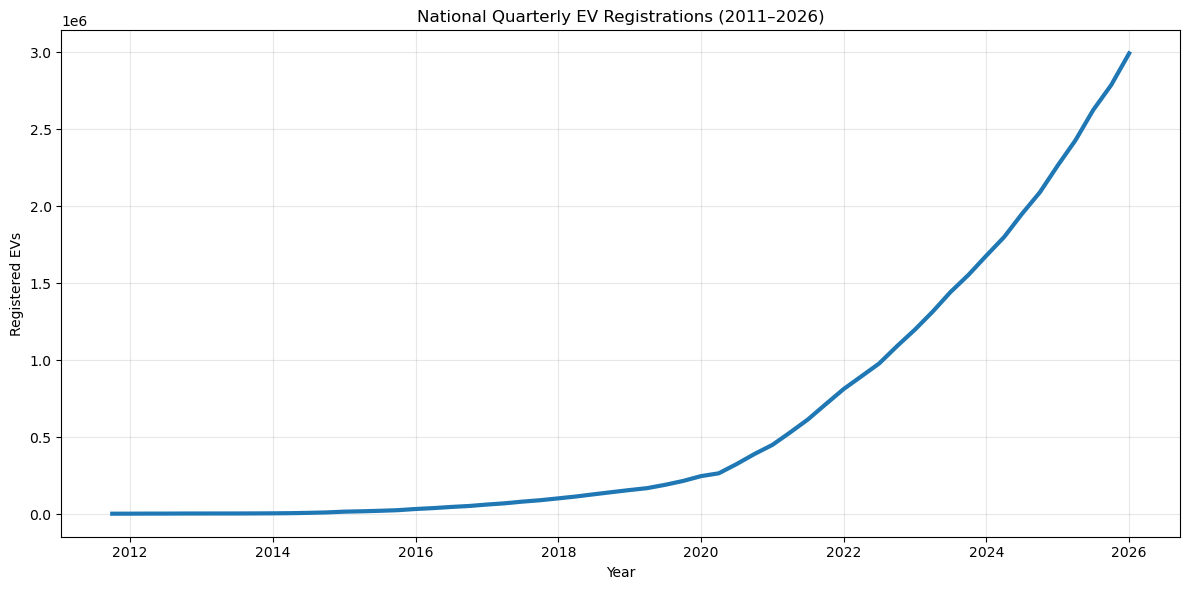

In [6]:
plt.figure(figsize=(12,6))

plt.plot(
    national_series["Date"],
    national_series["EV_Registrations"],
    linewidth=3
)

plt.title("National Quarterly EV Registrations (2011–2026)")
plt.xlabel("Year")
plt.ylabel("Registered EVs")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_folder / "national_ev_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Check Time Series Properties

Before fitting forecasting models, the time series is inspected for missing values and the total number of quarterly observations.

In [7]:
print("Number of observations:", len(national_series))

print("\nMissing values:")
print(national_series.isna().sum())

print("\nFirst quarter:", national_series["Quarter"].iloc[0])
print("Last quarter :", national_series["Quarter"].iloc[-1])

Number of observations: 58

Missing values:
Date                0
Quarter             0
EV_Registrations    0
dtype: int64

First quarter: 2011 Q4
Last quarter : 2026 Q1


## Train and Test Split

The quarterly time series is divided into training and testing datasets. Earlier observations are used for model training, while the most recent quarters are reserved to evaluate forecasting performance.

In [8]:
# Reserve the last 8 quarters for testing

train = national_series.iloc[:-8].copy()
test = national_series.iloc[-8:].copy()

print("Training observations:", len(train))
print("Testing observations :", len(test))

print("\nTraining period:")
print(train["Quarter"].iloc[0], "to", train["Quarter"].iloc[-1])

print("\nTesting period:")
print(test["Quarter"].iloc[0], "to", test["Quarter"].iloc[-1])

Training observations: 50
Testing observations : 8

Training period:
2011 Q4 to 2024 Q1

Testing period:
2024 Q2 to 2026 Q1


## Stationarity Test

The Augmented Dickey–Fuller (ADF) test is used to determine whether the national EV registration time series is stationary. A p-value below 0.05 indicates stationarity, while a larger value suggests that differencing may be required before model fitting.

In [9]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train["EV_Registrations"])

print("ADF Statistic :", round(adf_result[0], 4))
print("p-value       :", round(adf_result[1], 4))
print("Lags Used     :", adf_result[2])
print("Observations  :", adf_result[3])

print("\nCritical Values")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -0.4175
p-value       : 0.9071
Lags Used     : 3
Observations  : 46

Critical Values
1%: -3.5813
5%: -2.9268
10%: -2.6015


## Log Transformation and First-order Differencing

The original EV registration series exhibits a strong upward trend and increasing variance. A logarithmic transformation is applied to stabilise the scale, followed by first-order differencing to reduce the trend before examining the time-series characteristics.

The transformed series is assessed using the Augmented Dickey–Fuller (ADF) test. Although the transformation improves the behaviour of the series, the results should be interpreted together with the forecasting performance rather than relying solely on the ADF test.

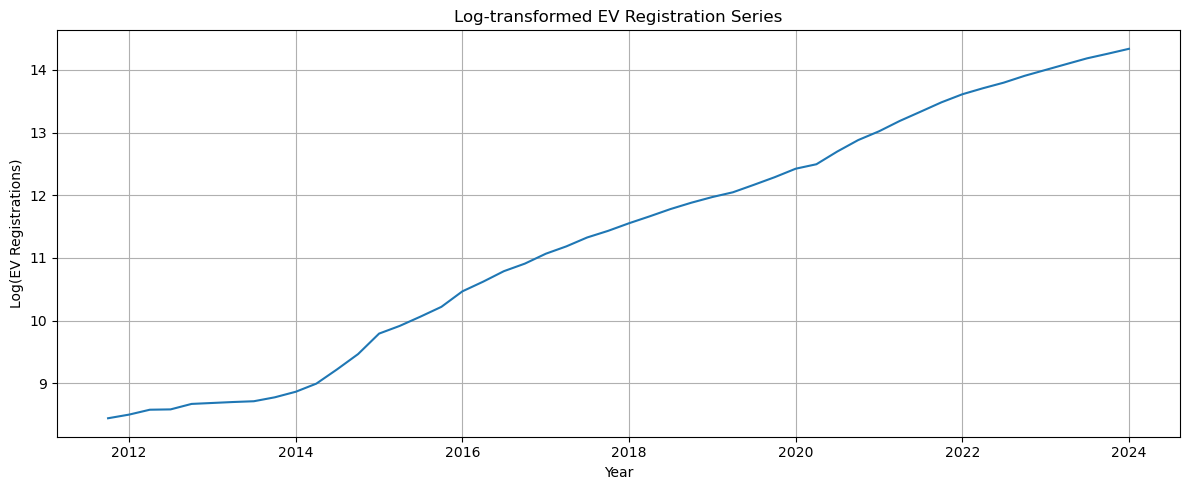

In [10]:
#Log Transformation

train_log = np.log(train["EV_Registrations"])

plt.figure(figsize=(12,5))
plt.plot(train["Date"], train_log)

plt.title("Log-transformed EV Registration Series")
plt.xlabel("Year")
plt.ylabel("Log(EV Registrations)")

plt.grid(True)
plt.tight_layout()
plt.savefig(
    figures_folder / "log_transformed_ev_series.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

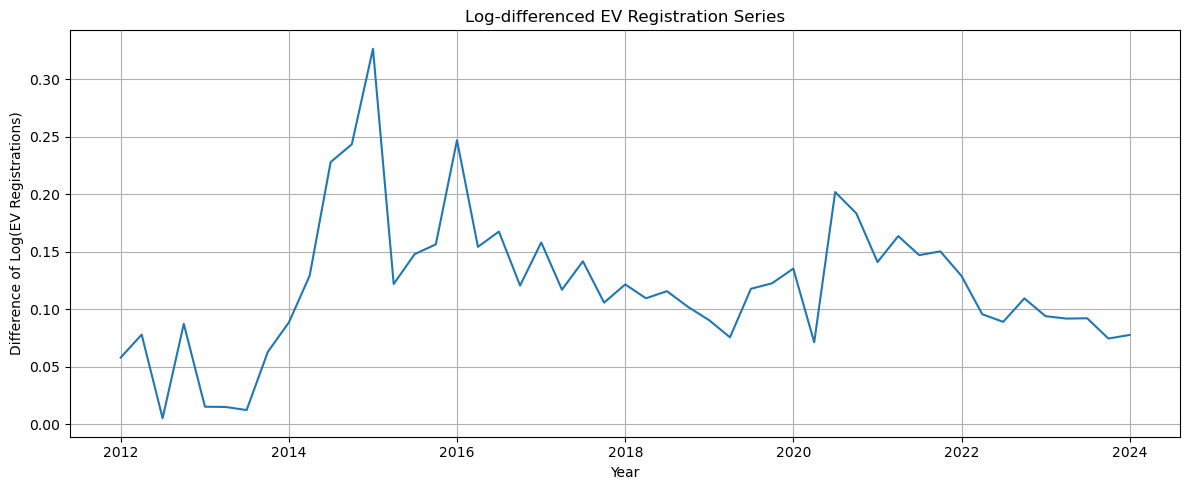

In [11]:
#Log Difference
train_log_diff = train_log.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(train["Date"].iloc[1:], train_log_diff)

plt.title("Log-differenced EV Registration Series")
plt.xlabel("Year")
plt.ylabel("Difference of Log(EV Registrations)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    figures_folder / "log_differenced_ev_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_log_diff)

print("ADF Statistic :", round(result[0], 4))
print("p-value       :", round(result[1], 4))

print("\nCritical Values")
for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -2.051
p-value       : 0.2647

Critical Values
1%: -3.5848
5%: -2.9283
10%: -2.6023


##  ACF and PACF Analysis

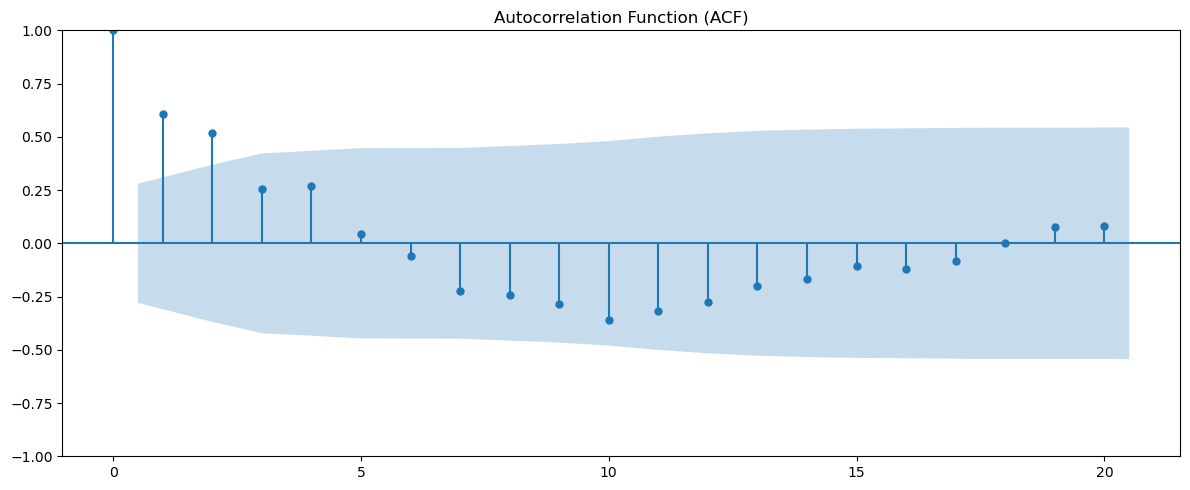

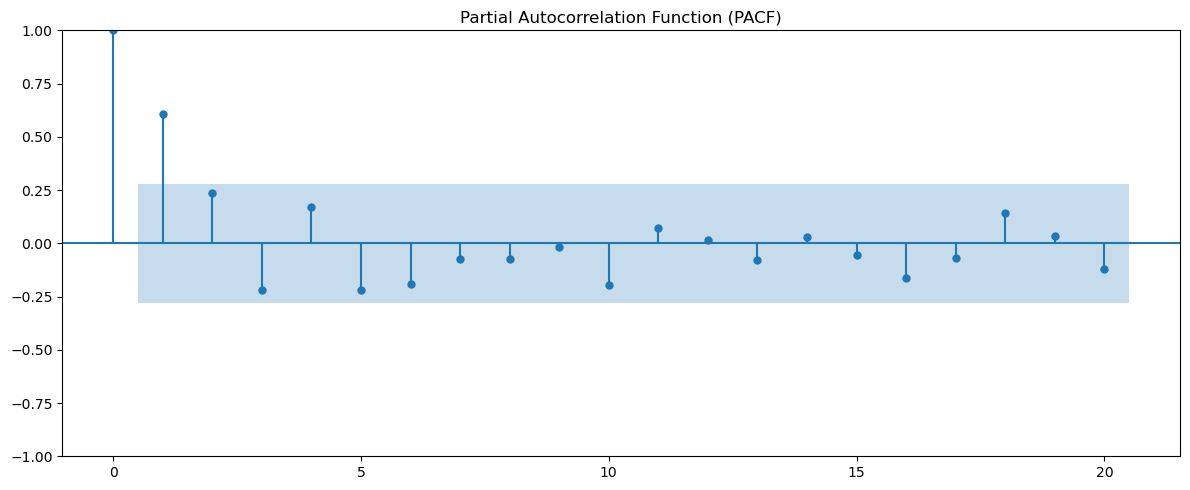

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF Plot
fig = plot_acf(train_log_diff, lags=20)

fig.set_size_inches(12, 5)

plt.title("Autocorrelation Function (ACF)")
plt.tight_layout()

plt.savefig(
    figures_folder / "acf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# PACF Plot
fig = plot_pacf(
    train_log_diff,
    lags=20,
    method="ywm"
)

fig.set_size_inches(12, 5)

plt.title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()

plt.savefig(
    figures_folder / "pacf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ARIMA Model Selection

An ARIMA (1,1,1) model was selected because it provides a simple autoregressive and moving-average representation while accounting for the non-stationary behaviour of the original series through first-order differencing.

The model is evaluated using a hold-out test set comprising the final eight quarters. Forecast accuracy is assessed using MAE, RMSE and MAPE.

In [14]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA model
arima_model = ARIMA(
    train["EV_Registrations"],
    order=(1,1,1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       EV_Registrations   No. Observations:                   50
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -518.948
Date:                Thu, 06 Aug 2026   AIC                           1043.896
Time:                        23:20:20   BIC                           1049.572
Sample:                             0   HQIC                          1046.049
                                 - 50                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.017     58.732      0.000       0.967       1.033
ma.L1         -0.1780      0.127     -1.403      0.161      -0.427       0.071
sigma2      9.373e+07   9.22e-10   1.02e+17      0.0

## Forecast EV Registrations

In [15]:
# Forecast over the testing period

forecast = arima_fit.forecast(steps=len(test))

forecast_df = test.copy()

forecast_df["Forecast"] = forecast.values

forecast_df.head()

,Date,Quarter,EV_Registrations,Forecast
50,2024-04-01,2024 Q2,1799851.0,1.802516e+06
51,2024-07-01,2024 Q3,1949503.0,1.925859e+06
52,2024-10-01,2024 Q4,2090088.0,2.049203e+06
53,2025-01-01,2025 Q1,2265036.0,2.172546e+06
54,2025-04-01,2025 Q2,2427221.0,2.295890e+06


## Forecast Performance

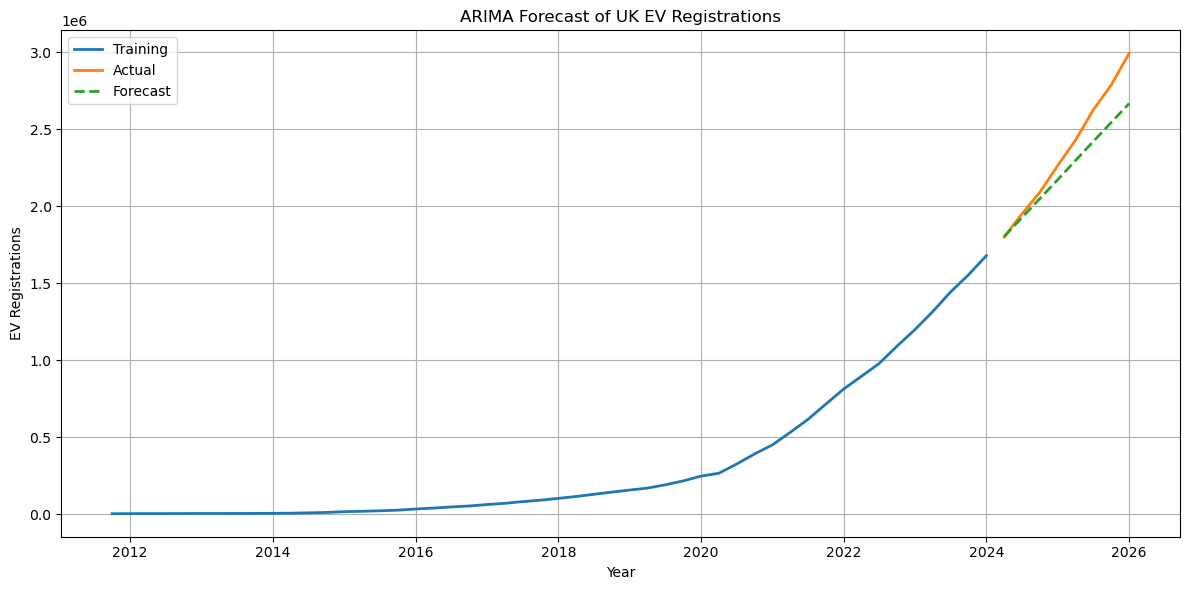

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    train["Date"],
    train["EV_Registrations"],
    label="Training",
    linewidth=2
)

plt.plot(
    test["Date"],
    test["EV_Registrations"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test["Date"],
    forecast_df["Forecast"],
    "--",
    linewidth=2,
    label="Forecast"
)

plt.title("ARIMA Forecast of UK EV Registrations")
plt.xlabel("Year")
plt.ylabel("EV Registrations")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    figures_folder / "arima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    forecast_df["EV_Registrations"],
    forecast_df["Forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        forecast_df["EV_Registrations"],
        forecast_df["Forecast"]
    )
)

mape = (
    np.mean(
        np.abs(
            (forecast_df["EV_Registrations"] -
             forecast_df["Forecast"])
            /
            forecast_df["EV_Registrations"]
        )
    )
    * 100
)

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 133,054.78
RMSE: 171,415.64
MAPE: 5.03%


## Residual Diagnostics

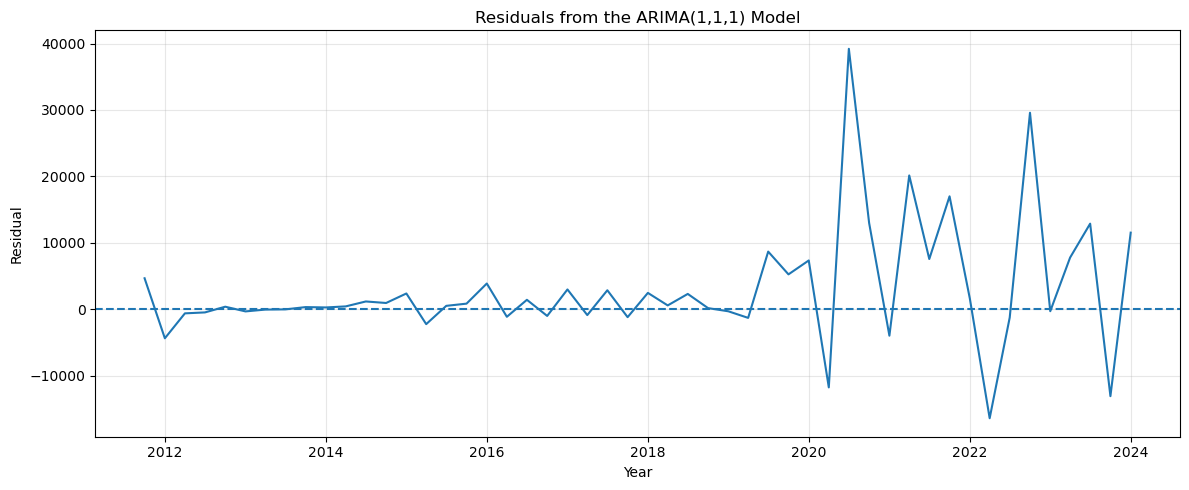

In [18]:
# Extract ARIMA residuals
residuals = pd.Series(
    arima_fit.resid,
    index=train.index,
    name="Residual"
)

plt.figure(figsize=(12, 5))

plt.plot(
    train["Date"],
    residuals,
    linewidth=1.5
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5
)

plt.title("Residuals from the ARIMA(1,1,1) Model")
plt.xlabel("Year")
plt.ylabel("Residual")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "arima_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

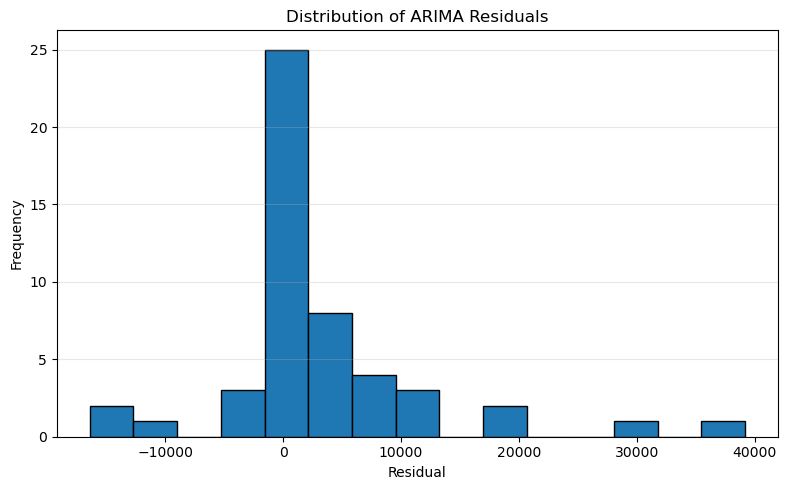

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals.dropna(),
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of ARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_folder / "arima_residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[4, 8],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
4,4.462248,0.347047
8,10.102002,0.257940


In [21]:
tables_folder.mkdir(parents=True, exist_ok=True)

forecast_df.to_csv(
    tables_folder / "arima_forecast_results.csv",
    index=False
)

print("Forecast results saved successfully.")

Forecast results saved successfully.


## Final Future Forecast

After evaluating the ARIMA model using the eight-quarter hold-out test set, the model is refitted using the complete national EV registration series. This allows future EV registrations to be projected beyond the final observed quarter of 2026 Q1.

The following forecast covers the next eight quarters, from 2026 Q2 to 2028 Q1. Forecast intervals are included to represent the uncertainty associated with longer-term projections.

In [22]:
final_arima_model = ARIMA(
    national_series["EV_Registrations"],
    order=(1, 1, 1)
)

final_arima_fit = final_arima_model.fit()

print(final_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       EV_Registrations   No. Observations:                   58
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -621.326
Date:                Thu, 06 Aug 2026   AIC                           1248.652
Time:                        23:20:20   BIC                           1254.781
Sample:                             0   HQIC                          1251.034
                                 - 58                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.009    109.530      0.000       0.982       1.018
ma.L1         -0.2996      0.110     -2.729      0.006      -0.515      -0.084
sigma2      1.488e+08   3.17e-10   4.69e+17      0.0

In [23]:
# Forecast the next 8 quarters
future_forecast = final_arima_fit.get_forecast(steps=8)

forecast_mean = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int()

future_df = pd.DataFrame({
    "Forecast": forecast_mean,
    "Lower_95CI": forecast_ci.iloc[:, 0],
    "Upper_95CI": forecast_ci.iloc[:, 1]
})

future_df.index = [
    "2026 Q2",
    "2026 Q3",
    "2026 Q4",
    "2027 Q1",
    "2027 Q2",
    "2027 Q3",
    "2027 Q4",
    "2028 Q1"
]

future_df

,Forecast,Lower_95CI,Upper_95CI
2026 Q2,3.186301e+06,3.162392e+06,3.210210e+06
2026 Q3,3.381103e+06,3.333939e+06,3.428267e+06
2026 Q4,3.575903e+06,3.501611e+06,3.650194e+06
2027 Q1,3.770700e+06,3.665740e+06,3.875660e+06
2027 Q2,3.965496e+06,3.826652e+06,4.104340e+06
2027 Q3,4.160290e+06,3.984612e+06,4.335968e+06
2027 Q4,4.355082e+06,4.139831e+06,4.570333e+06
2028 Q1,4.549872e+06,4.292483e+06,4.807260e+06


## Future Forecast of UK EV Registrations

The validated ARIMA model was refitted using the complete national EV registration time series and used to forecast the next eight quarters. Historical observations and future forecasts are displayed together, while the shaded confidence interval illustrates the increasing uncertainty associated with longer-term predictions.

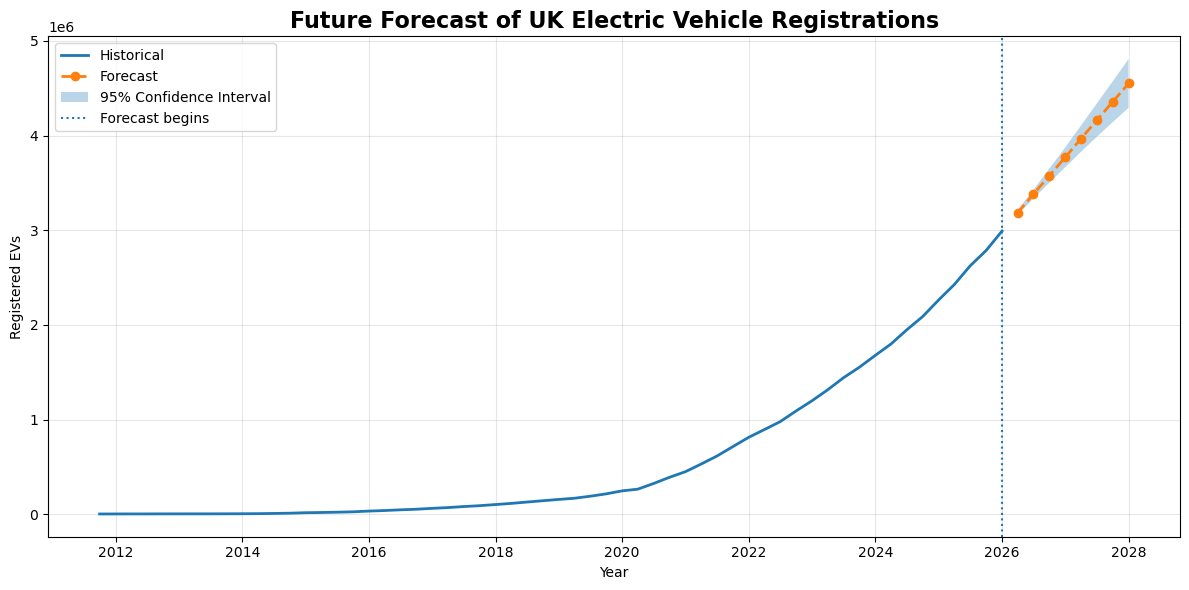

In [24]:
# Historical data + future ARIMA forecast

# Convert historical dates to datetime
historical_dates = pd.to_datetime(national_series["Date"])

# Create future quarterly dates:
# 2026 Q2 to 2028 Q1
future_dates = pd.date_range(
    start="2026-04-01",
    periods=8,
    freq="QS"
)

# Add the dates to the future forecast table
future_plot_df = future_df.copy()
future_plot_df["Date"] = future_dates

plt.figure(figsize=(12, 6))

# Historical observations
plt.plot(
    historical_dates,
    national_series["EV_Registrations"],
    linewidth=2,
    label="Historical"
)

# Future forecast
plt.plot(
    future_plot_df["Date"],
    future_plot_df["Forecast"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

# 95% confidence interval
plt.fill_between(
    future_plot_df["Date"],
    future_plot_df["Lower_95CI"],
    future_plot_df["Upper_95CI"],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.axvline(
    pd.Timestamp("2026-01-01"),
    linestyle=":",
    linewidth=1.5,
    label="Forecast begins"
)

plt.title(
    "Future Forecast of UK Electric Vehicle Registrations",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Registered EVs")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_folder / "Figure_09_Future_EV_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
future_df.to_csv(
    tables_folder / "future_ev_forecast.csv"
)

print("Future forecast saved successfully.")

Future forecast saved successfully.
